## Imports

In [ ]:
import os
import time
import torch
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from pathlib import Path
from torch import nn
from torchsummary import summary
from torch.utils.data import DataLoader
from tqdm import tqdm

from ml_events_utils import MLEventsDataset, scale_target, train_loop, valid_loop
from ml_events_utils.models import FFNN_BatchNorm, FFNN_BatchNorm_no_output, FFNN_paper

print('numpy', np.__version__)
print('pandas', pd.__version__)
print('torch', torch.__version__)

# Turn off file validation for pydevd to avoid issues in some environments
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"


numpy 1.26.4
pandas 2.3.3
torch 2.9.0+cu128


## Data Handling

### Load the momentum and weight data from the `.ml` files.

In [2]:
# Set fixed random number seed
# torch.manual_seed(42)

# Example usage for large files:
# file = Path("examplary_eventfiles/*.ml")
file = Path("event_files/pwgevents-*.ml")

dataset = MLEventsDataset(file,
                          labels = ["LL",],
                        #   transform=None,
                          target_transform=scale_target,  # Scale target by 1000
                          cache_events=True)  # Caching enabled
print(f"Dataset info: {dataset.get_file_info()}")


Found 4717273 events in [PosixPath('event_files/pwgevents-*.ml')]
Dataset info: {'total_files_size_mb': 2159.484043121338, 'num_events': 4717273, 'cache_enabled': True}


Examine the dataset a bit:

In [3]:
# Get first sample
if len(dataset) > 0:
    features, labels = dataset[0]
    print(f"Features shape: {features.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"First event features: {features[:8]}...")  # Show first 8 components
    print(f"First event labels: {labels}")

# Create DataLoader with multiple workers for better performance
n_workers = 4
b_size    = 32

play_dataloader = DataLoader(
    dataset,
    batch_size=b_size,  # Larger batch size for efficiency
    shuffle=True,
    num_workers=n_workers,  # Use multiple workers for large files
    pin_memory=True  # Faster GPU transfer
)

print(f"\nDataLoader created with batch_size={b_size}, num_workers={n_workers}")

# Test iteration (only first batch to avoid long output)
for batch_idx, (batch_features, batch_labels) in enumerate(play_dataloader):
    print(f"Batch {batch_idx}: features shape {batch_features.shape}, labels shape {batch_labels.shape}")
    input_dim = batch_features.shape[1]
    print(f"{input_dim = }")
    break  # Only show first batch

Features shape: torch.Size([16])
Labels shape: torch.Size([1])
First event features: tensor([-19.5224,  16.1917, -39.6007,  47.0267,   4.6771, -62.2295,   1.2910,
         62.4183])...
First event labels: tensor([0.6351])

DataLoader created with batch_size=32, num_workers=4


/home/thA363a/linder/Packages/miniforge3/envs/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/home/thA363a/linder/Packages/miniforge3/envs/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch 0: features shape torch.Size([32, 16]), labels shape torch.Size([32, 1])
input_dim = 16


### Hyperparameters

In [4]:
# Hyperparameters
learning_rate = 1e-2
batch_size    = 128
epochs        = 1000

### Split the dataset into training, validation and test sets

In [5]:
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.6, 0.2, 0.2], generator=generator)

print(f"Train dataset size:      {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size:       {len(test_dataset)}")

# Create DataLoader with multiple workers for better performance
n_workers = 8

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,  # Larger batch size for efficiency
    shuffle=True,
    num_workers=n_workers,  # Use multiple workers for large files
    pin_memory=True  # Faster GPU transfer
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,  # Larger batch size for efficiency
    shuffle=True,
    num_workers=n_workers,  # Use multiple workers for large files
    pin_memory=True  # Faster GPU transfer
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,  # Larger batch size for efficiency
    shuffle=True,
    num_workers=n_workers,  # Use multiple workers for large files
    pin_memory=True  # Faster GPU transfer
)


print(f"\nDataLoader created with batch_size={batch_size}, num_workers={n_workers}")

# Test iteration (only first batch to avoid long output)
for batch_idx, (batch_features, batch_labels) in enumerate(train_dataloader):
    print(f"Batch {batch_idx}: features shape {batch_features.shape}, labels shape {batch_labels.shape}")
    break  # Only show first batch

Train dataset size:      2830364
Validation dataset size: 943455
Test dataset size:       943454

DataLoader created with batch_size=128, num_workers=8
Batch 0: features shape torch.Size([128, 16]), labels shape torch.Size([128, 1])


Play around with the batch normalisation

In [6]:
# data (batch size, number of features)
x = torch.rand(16, 5)
print(f"{x = }")
print(f"{x.mean(dim=0) = }")  # mean for each feature across the batch
print(f"{x.std(dim=0) = }")  # standard deviation for each feature across the batch

# layers
bn = nn.BatchNorm1d(5)

x_normed = bn(x)
print(f"{x_normed = }")
print(f"{x_normed.mean(dim=0) = }")
print(f"{x_normed.std(dim=0) = }")

x = tensor([[0.7775, 0.6336, 0.8589, 0.1291, 0.2883],
        [0.0208, 0.9282, 0.2525, 0.0666, 0.7253],
        [0.8226, 0.6264, 0.8902, 0.1388, 0.6187],
        [0.2276, 0.7498, 0.1428, 0.1719, 0.3739],
        [0.3186, 0.3263, 0.3069, 0.9822, 0.2872],
        [0.6839, 0.2438, 0.0586, 0.2491, 0.4251],
        [0.4600, 0.8793, 0.4695, 0.4121, 0.2772],
        [0.1930, 0.3809, 0.1413, 0.2767, 0.4858],
        [0.6715, 0.6635, 0.4731, 0.1856, 0.2939],
        [0.2181, 0.2363, 0.3305, 0.6147, 0.3204],
        [0.8812, 0.4999, 0.9560, 0.4546, 0.9656],
        [0.6101, 0.2782, 0.7110, 0.0835, 0.8971],
        [0.7938, 0.7789, 0.9519, 0.0952, 0.4141],
        [0.4639, 0.9637, 0.7821, 0.3439, 0.3720],
        [0.2804, 0.8160, 0.9264, 0.8246, 0.0834],
        [0.6551, 0.4194, 0.7115, 0.9793, 0.5655]])
x.mean(dim=0) = tensor([0.5049, 0.5890, 0.5602, 0.3755, 0.4621])
x.std(dim=0) = tensor([0.2675, 0.2518, 0.3231, 0.3141, 0.2386])
x_normed = tensor([[ 1.0524,  0.1828,  0.9549, -0.8103, -0.7521],


## Specify the loss function

Use the *cross entropy loss* for multi class problems and the *binary cross-entropy* for binary classification.

In [9]:
# Initialize the loss function

# Multi class classification:
# loss_fn = nn.CrossEntropyLoss()

# binary cross-entropy loss for binary classification: The targets are supposed to be 0 or 1 (nothing in between).
# loss_fn = nn.BCELoss()

# Mean Squared Error loss for regression tasks
loss_fn = nn.MSELoss()

# loss_fn = nn.SmoothL1Loss()




Specify the computation device (cpu or gpu).

In [10]:
# in torch/pytorch data and models need to be moved in the specific processing unit
# this code snippet allows to set the variable "device" according to available resoirce (cpu or cuda gpu)

if torch.cuda.is_available():
  print('number fo devices: ', torch.cuda.device_count())
  print(torch.cuda.get_device_name(0))

device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

Computation device: cpu



Set the model and choose an optimizer.

In [ ]:
# input_dim = 16
# model = FFNN(input_dim=input_dim, width= 100)
# model = FFNN_BatchNorm(input_dim=input_dim, width=1000)
model = FFNN_BatchNorm_no_output(input_dim=input_dim, width=1000)

model.to(device)
print('model is on GPU: ',next(model.parameters()).is_cuda)

# Initialize the optimizer
# optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Alternative
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# RMSprop optimizer, set to the parameters Giovanni and Mathieu used in their studies
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001, alpha=0.99, weight_decay=0.0, momentum=0.0)


model is on GPU:  False


In [12]:
# test implementation on one batch before to train
# xb, yb = next(iter(play_dataloader))

test_batch_size = 10
xb = torch.randn(test_batch_size, input_dim)
yb = torch.randn(test_batch_size)

# put tensors on device
xb = xb.type(torch.float).to(device)
yb = yb.type(torch.float).to(device)

print(f"{xb.shape = }")
print(f"{yb.shape = }")

# prediction
pred = model(xb)
print('output shape: ', pred.shape)
print(f"{pred.squeeze().shape = }")


# loss and metric
loss = loss_fn(pred, torch.unsqueeze(yb,1))  # Bring yb to shape (batch_size, 1) to match pred shape.
# metric = binary_accuracy(pred, torch.unsqueeze(yb,1))

print('loss: ', loss.item())
# print('metric: ', metric.item())



xb.shape = torch.Size([10, 16])
yb.shape = torch.Size([10])
output shape:  torch.Size([10, 1])
pred.squeeze().shape = torch.Size([10])
loss:  1.9252887964248657


## Train

In [ ]:
# if torch.cuda.is_available():
#   summary(model.cuda(), input_size=(1,input_dim))
# else:
#   summary(model, input_size=(1,input_dim))



hist_loss     = []
hist_val_loss = []
hist_lr       = []

# Early stopping parameters
best_val_loss = float('inf')
patience = 25
patience_counter = 0
best_model_state = None

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3,
)
# scheduler for multi step decay lr schedule
# Decays the learning rate of each parameter group by gamma once the number of epoch reaches one of the milestones
# lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20,40,60], gamma=0.1)

print(f"Starting training for {epochs} epochs...")
print(f"Early stopping patience: {patience}")

for epoch in range(epochs):
    epoch_start_time = time.time()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"\nEpoch {epoch + 1}/{epochs}")
    print(f"Learning Rate: {current_lr:.2e}")
    print("-" * 50)

    # Training phase
    train_loss = train_loop(train_dataloader, model, loss_fn, optimizer, device, print_freq = 2500)
    hist_loss.append(train_loss)
    hist_lr.append(current_lr)

    # Validation phase
    valid_loss = valid_loop(val_dataloader,   model, loss_fn, device)
    hist_val_loss.append(valid_loss)

    # Learning rate scheduling
    scheduler.step(valid_loss)

    # Early stopping check
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        patience_counter = 0
        # Save best model state
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"✓ New best validation loss: {best_val_loss:.6f}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")

    epoch_time = time.time() - epoch_start_time
    print(f"Epoch time: {epoch_time:.2f} seconds")
    print(f"Train Loss: {train_loss:.6f} | Val Loss: {valid_loss:.6f}")

    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        print(f"Best validation loss: {best_val_loss:.6f}")
        break

# Save final model
model_filename = f"{model.__class__.__name__}_model_weights_final.pt"
torch.save(model.state_dict(), model_filename)

# Load best model weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nLoaded best model with validation loss: {best_val_loss:.6f}")


hist_loss     = np.array(hist_loss)
hist_val_loss = np.array(hist_val_loss)
hist_lr       = np.array(hist_lr)

np.savetxt(f"{model.__class__.__name__}_train_loss.csv",     hist_loss,     delimiter=',')
np.savetxt(f"{model.__class__.__name__}_val_loss.csv",       hist_val_loss, delimiter=',')
np.savetxt(f"{model.__class__.__name__}_learning_rates.csv", hist_lr,       delimiter=',')

# Save best model separately
if best_model_state is not None:
    best_model_filename = f"{model.__class__.__name__}_model_weights_best.pt"
    torch.save(best_model_state, best_model_filename)
    print(f"Best model saved as: {best_model_filename}")


print(f"Final model saved as: {model_filename}")
print("Training completed!")

# Print training summary
print(f"\nTraining Summary:")
print(f"Total epochs: {len(hist_loss)}")
print(f"Final train loss: {hist_loss[-1]:.6f}")
print(f"Final validation loss: {hist_val_loss[-1]:.6f}")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting training for 1000 epochs...
Early stopping patience: 25

Epoch 1/1000
Learning Rate: 1.00e-02
--------------------------------------------------


/home/thA363a/linder/Packages/miniforge3/envs/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


loss: 1.723074  [320000/2830364]
loss: 1.922283  [640000/2830364]
loss: 1.663819  [960000/2830364]
loss: 1.024338  [1280000/2830364]
loss: 2.249690  [1600000/2830364]
loss: 2.292136  [1920000/2830364]
loss: 1.415954  [2240000/2830364]
loss: 1.120652  [2560000/2830364]
Validation Error: 
 Avg valid loss: 1.484495, Avg L1 Loss: 0.843377

✓ New best validation loss: 1.484495
Epoch time: 203.10 seconds
Train Loss: 1.874134 | Val Loss: 1.484495

Epoch 2/1000
Learning Rate: 1.00e-02
--------------------------------------------------
loss: 1.163590  [320000/2830364]
loss: 1.367324  [640000/2830364]
loss: 2.127199  [960000/2830364]
loss: 1.215605  [1280000/2830364]
loss: 1.360414  [1600000/2830364]
loss: 1.362820  [1920000/2830364]
loss: 0.749752  [2240000/2830364]
loss: 0.925627  [2560000/2830364]
Validation Error: 
 Avg valid loss: 1.375416, Avg L1 Loss: 0.812447

✓ New best validation loss: 1.375416
Epoch time: 204.16 seconds
Train Loss: 1.329106 | Val Loss: 1.375416

Epoch 3/1000
Learning 

## Loss


Plotting training history, using best model weights: True


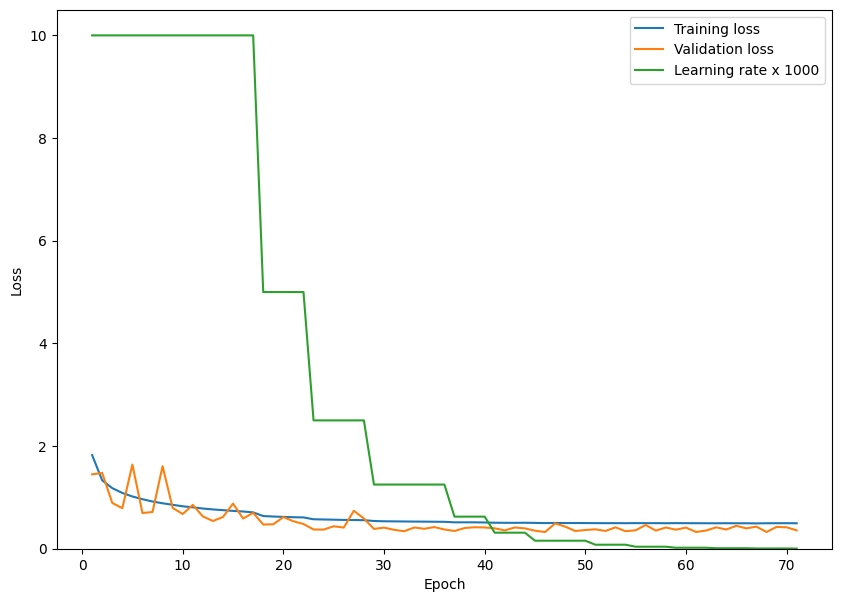

In [ ]:
print(f"Plotting training history, using best model weights: {best_model_state is not None}")
plt.figure(figsize=(10, 7))

plt.plot(range(1,len(hist_loss)+1),     np.array(hist_loss),     label="Training loss")
plt.plot(range(1,len(hist_val_loss)+1), np.array(hist_val_loss), label="Validation loss")
plt.plot(range(1,len(hist_lr)+1),       np.array(hist_lr)*1000,  label="Learning rate x 1000")

plt.ylim(ymin=0)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Check network on random event:
```
<event>
  3.016570943E+01  4.510460277E+01 -1.552387738E+02  1.644489954E+02
 -5.944532656E+01  1.420361466E+02 -3.064427199E+02  3.429506588E+02
 -3.520454553E+01  5.968701995E+01 -2.189955679E+01  7.267386713E+01
 -7.860515623E+01 -7.434789122E-01 -9.197268046E+01  1.209888313E+02
<rwgt>
<weight id='LL'> 0.360386982E-02 </weight>
<weight id='LT'> 0.914721633E-03 </weight>
<weight id='TL'> 0.168988248E-02 </weight>
<weight id='TT'> 0.160581823E-01 </weight>
</rwgt>
</event>
```

In [ ]:
# model = FFNN_BatchNorm(input_dim=input_dim, width= 100) # we do not specify ``weights``, i.e. create untrained model
# model.load_state_dict(torch.load(f"{model.__class__.__name__}_model_weights_best.pt", weights_only=True))

model.eval()

test_tensor = torch.tensor([ 3.016570943E+01,  4.510460277E+01, -1.552387738E+02, 1.644489954E+02,
                            -5.944532656E+01,  1.420361466E+02, -3.064427199E+02, 3.429506588E+02,
                            -3.520454553E+01,  5.968701995E+01, -2.189955679E+01, 7.267386713E+01,
                            -7.860515623E+01, -7.434789122E-01, -9.197268046E+01, 1.209888313E+02])

res = model(test_tensor.unsqueeze(0).to(device))
print(f"res = {res.item()/ 1000:.2e}")

res = -9.09e-04


In [ ]:
#test the trained model

# let's test it on cpu
# model.to(torch.device("cpu"))

# X_test_pt = X_test_pt.type(torch.float).to(torch.device("cpu"))
# res = model(X_test_pt)

In [ ]:
# print('Test accuracy: ',binary_accuracy(res, torch.unsqueeze(Y_test_pt,1)).item())

In [ ]:
# !jupyter kernelspec list